In [90]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import Select
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time

In [98]:
driver = webdriver.Chrome()
driver.get("https://vahan.parivahan.gov.in/vahan4dashboard/vahan/dashboardview.xhtml")

In [99]:
states = ["Andhra Pradesh","Assam", "Delhi", "Gujarat", "Haryana", "Jharkhand", "Karnataka", "Kerala", "Maharashtra", "Madhya Pradesh", 
          "Odisha", "Punjab", "Rajasthan", "Tamil Nadu", "Uttarakhand", "Uttar Pradesh", "West Bengal"]
v_data=[]
for state_name in states:

    driver.find_element(By.XPATH, "/html/body/form/div[1]/div/div/div/div/div[2]/div[2]/div/div[3]/span").click() #dropdown
    
    driver.find_element(By.XPATH, f"//li[contains(text(),'{state_name}')]").click() #state
    
    time.sleep(2)
    
    driver.find_element(By.XPATH, "/html/body/form/div[1]/div/div/div/div/div[4]/div/button").click() #refresh
    
    time.sleep(2)
    
    driver.find_element(By.XPATH, "//*[contains(text(),'Till Today')]").click() #till today
    
    time.sleep(2)
    
    rows = driver.find_elements(By.XPATH, "//*[@id='datatable_VhClass_data']/tr") #table_rows
    
    v_category = None

    for row in rows:
        try:
            if "ui-widget-header" in row.get_attribute("class"):
                 v_category = row.text
                
            else:
                 cols = row.find_elements(By.TAG_NAME, "td")
            if len(cols) == 2:
             vehicle = cols[0].text
             count = cols[1].text

            v_data.append([state_name, current_category, vehicle, count])
        except:
            continue
    

In [81]:
import pandas as pd
import numpy as np

df = pd.DataFrame(v_data, columns=["State", "Vehicle_Category", "Vehicle_Class", "Count"])

df["Count"] = df["Count"].str.replace(",", "").astype(int)
df["Vehicle_Class"] = df["Vehicle_Class"].str.replace("-", "").str.strip()

print(df.tail())

            State            Vehicle_Category                 Vehicle_Class  \
1131  West Bengal  Non Transport\n3,28,90,756      Trailer For Personal Use   
1132  West Bengal  Non Transport\n3,28,90,756         Quadricycle (Private)   
1133  West Bengal  Non Transport\n3,28,90,756  Armoured/Specialised Vehicle   
1134  West Bengal  Non Transport\n3,28,90,756         Vintage Motor Vehicle   
1135  West Bengal  Non Transport\n3,28,90,756                MCycle/Scooter   

         Count  
1131        13  
1132         1  
1133        24  
1134       103  
1135  14021303  


In [82]:
print(df.shape)
print(df["State"].nunique())

(1136, 4)
17


In [35]:
df.to_csv("vahan_state_data.csv", index=False)

In [38]:
abc= df.groupby("State").agg({
    'Count': 'sum'}).reset_index()
abc.head()

,State,Count
0,Andhra Pradesh,19122865
1,Assam,7065164
2,Delhi,16020610
3,Gujarat,28380695
4,Haryana,14622084


In [39]:
abc['Count'].sum()

np.int64(381350878)

In [40]:
goods_carrier = df[df['Vehicle_Class'] == 'Goods Carrier']
goods_carrier = goods_carrier[['State', 'Count']]

In [41]:
goods_carrier

,State,Count
1,Andhra Pradesh,573892
75,Assam,305707
156,Delhi,413299
177,Gujarat,1095946
248,Haryana,769771
347,Jharkhand,345401
377,Karnataka,1375223
450,Kerala,613048
522,Maharashtra,1800283
596,Madhya Pradesh,632399


In [42]:
goods_carrier.to_csv("goods_carrier.csv", index=False)

In [52]:
goods_carrier['Share'] = goods_carrier['Count'] / goods_carrier['Count'].sum()
goods_carrier['Workforce'] = (goods_carrier['Share'] *150).round().astype(int)

In [55]:
goods_carrier.to_csv("goods_carrier.csv", index=False)

In [58]:
goods_carrier = goods_carrier.sort_values('Workforce',ascending=False)
top5 = goods_carrier.head()
top5 = top5.set_index("State")
print('Top 5 states\n',top5)

Top 5 states
                  Count     Share  Workforce
State                                      
Maharashtra    1800283  0.133317         20
Tamil Nadu     1414787  0.104769         16
Karnataka      1375223  0.101840         15
Uttar Pradesh  1242576  0.092017         14
Gujarat        1095946  0.081158         12


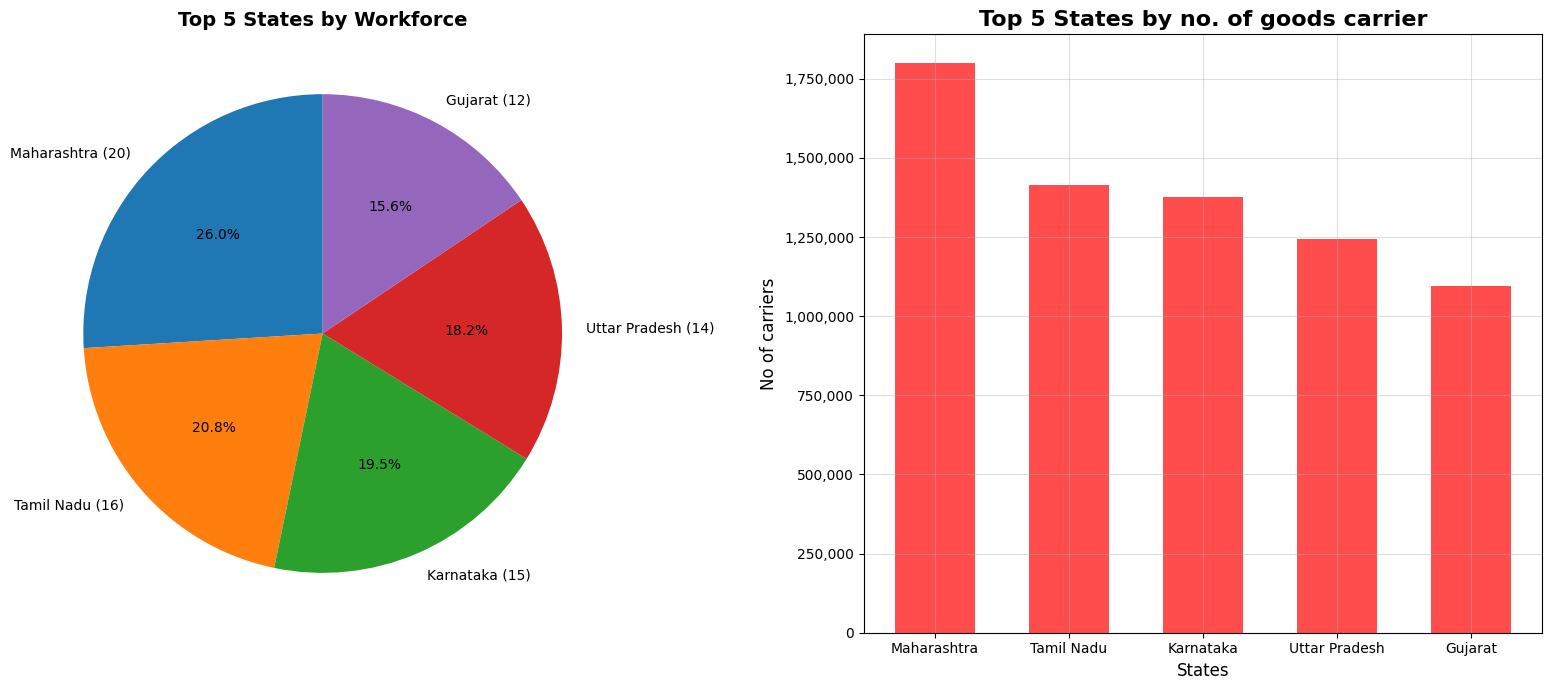

In [107]:
import matplotlib.pyplot as plt
fig,axes = plt.subplots(1,2,figsize=(16, 7))
top5['labels'] = top5.index + " (" + (top5['Workforce'].astype(str)) + ")"
axes[0].pie(
    top5['Workforce'],
    labels=top5['labels'],
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Top 5 States by Workforce', fontsize=14, fontweight='bold')

axes[1].bar(top5.index, top5['Count'], width = 0.6, color='red', alpha=0.7)
axes[1].set_title('Top 5 States by no. of goods carrier',fontsize=16,fontweight='bold')
axes[1].set_xlabel('States',fontsize=12)
axes[1].set_ylabel('No of carriers',fontsize=12)
axes[1].ticklabel_format(style='plain', axis='y')
axes[1].grid(True,alpha=0.4)
import matplotlib.ticker as mticker

ax = plt.gca()
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.savefig('top5 states.png', dpi=300)
plt.tight_layout()
plt.show()